# L-Maze: Comparison

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [14]:
import numpy as np
np.set_printoptions(precision=2)

In [15]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define A L-Maze Grid World 

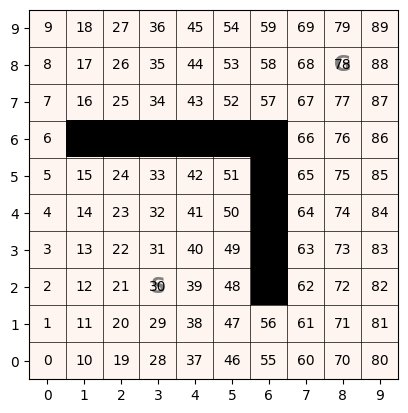

In [16]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

env.image()

In [17]:
# For comparison
avg_returns = {}
avg_ep_length = {}

In [18]:
from gym_classics.performance import plot_returns, plot_ep_lens

## Comparison

To compare the algorithm, we use: 
* Episodes: 5000 episodes.
* Exploration: a schedule that reduces $\epsilon$ over the first 2500 episodes.
* Learning rate: $\alpha$ between 0.01 and 0.001.
* Discount rate: a $\gamma=0.99$ to encourage the algorithm to find the shorter path.

In [19]:
from gym_classics.algorithms.schedules import LinearDecaySchedule

eps_schedule = LinearDecaySchedule(.5, 0.0001, 2500)

### Monte Carlo Methods

I use here only Monte-Carlo Control with exploring starts. Monte-Carlo Control with $\epsilon$-soft policy can also be used. 

MC Control (Incremental): 100%|██████████| 5000/5000 [00:11<00:00, 437.93it/s]


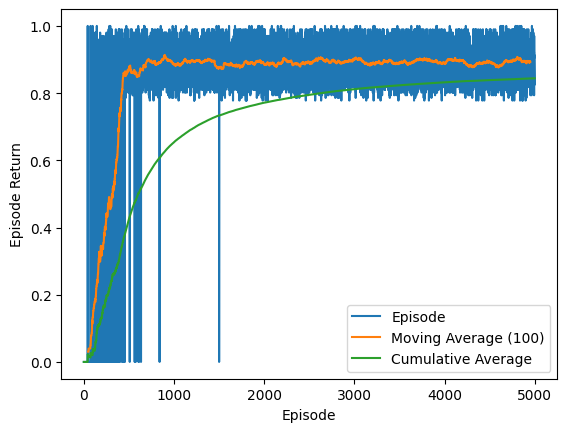

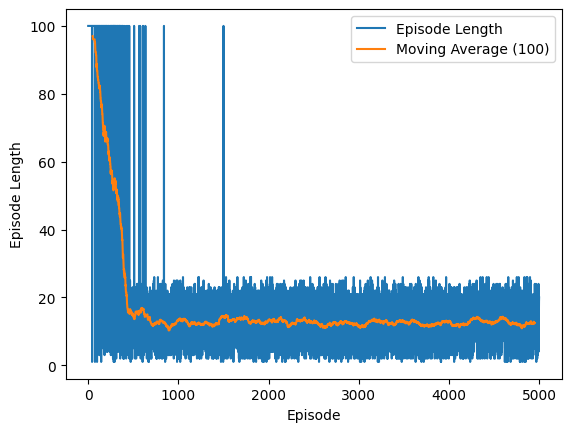

In [32]:
from gym_classics.algorithms.monte_carlo_methods import MC_control_ES

policy, Q, history = MC_control_ES(env, n=5000, discount=.99, history = True)

plot_returns(history["returns"])
plot_ep_lens([len(x) for x in history["episodes"]])

# We cannot use the results from exploring starts because episodes do not start from the start state
avg_returns["MC Control ES"] = np.nan
avg_ep_length["MC Control ES"] = np.nan

Note: The remaining variability comes from the random restarts.

### Tabular Temporal Differencing Methods

We use:
* Sarsa
* Q-Learning

Sarsa: 100%|██████████| 5000/5000 [00:18<00:00, 274.24it/s]


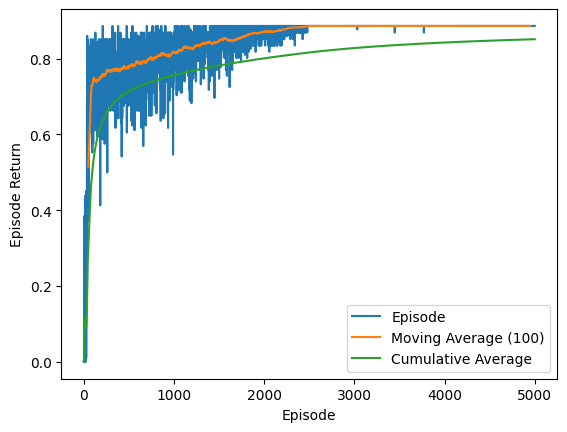

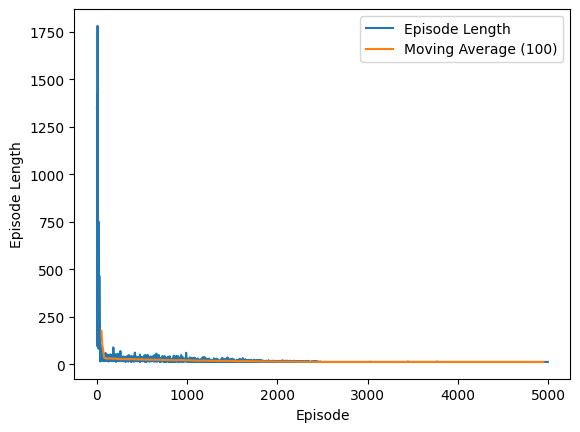

In [21]:
from gym_classics.algorithms.temporal_difference_learning import Sarsa

Q, history = Sarsa(env, n=5000, discount=.99, alpha = 0.01, epsilon = eps_schedule, history = True)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Sarsa(0)"] = np.mean(history["returns"])
avg_ep_length["Sarsa(0)"] = np.mean(history["ep_lens"])

Q-Learning: 100%|██████████| 5000/5000 [00:10<00:00, 498.47it/s]


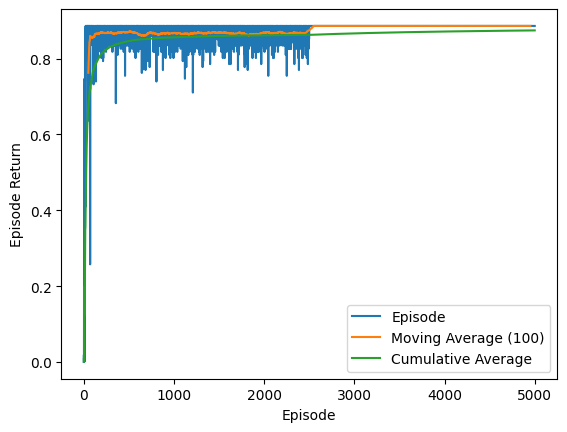

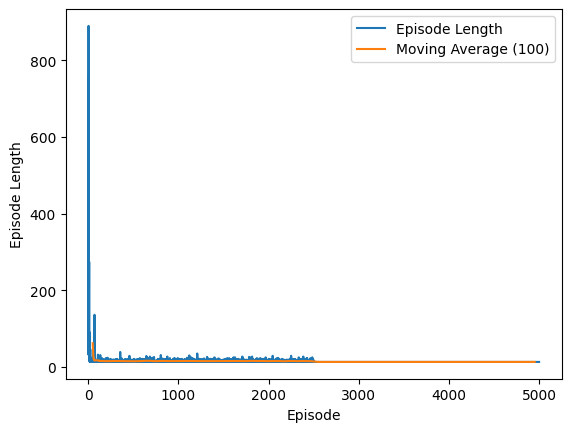

In [22]:
from gym_classics.algorithms.temporal_difference_learning import Q_learning
from gym_classics.algorithms.schedules import StepSchedule

Q, history = Q_learning(env, n=5000, discount=.99, alpha = 0.01, 
                        epsilon = StepSchedule(high_value=0.1, low_value=0, steps=2500), history = True)
# Note: Q-Learning is off-policy and does not need a epsilon schedule

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Q-learning"] = np.mean(history["returns"])
avg_ep_length["Q-learning"] = np.mean(history["ep_lens"])

### Approximation Methods

We use Fourier basis features with:
* Sarsa(0)
* Sarsa($\lambda$) (eligibility traces)
* REINFORCE

In [23]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

# overwrite state_features for the semi-gradient Sarsa implementation with Fourier basis features
def state_features(s, env):
    return trans_fb(env.id2state(s))

Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [00:35<00:00, 142.42it/s]


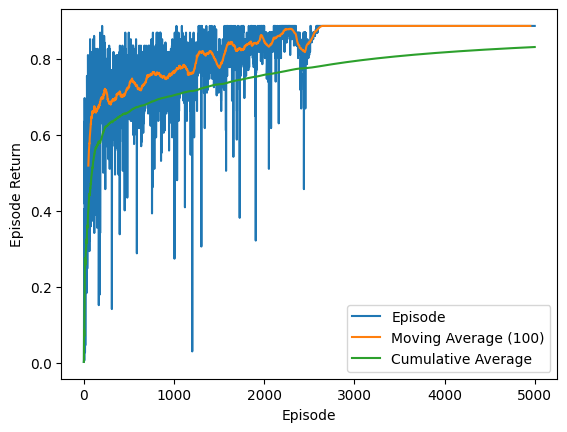

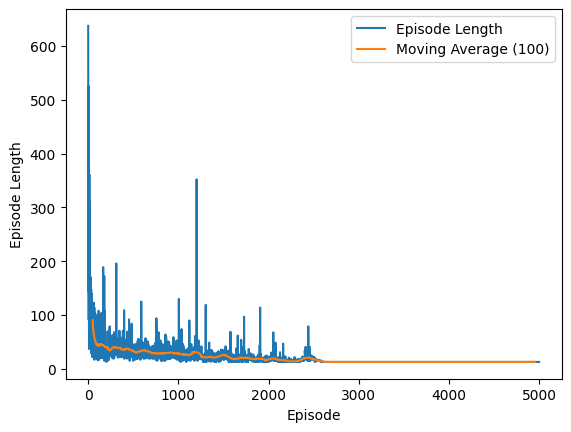

In [24]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0
gym_classics.algorithms.linear_approximation.state_features = state_features

w, history = semi_gradient_Sarsa_0(env, n=5000, gamma=.99, alpha = 0.01, epsilon = eps_schedule, history = True)
plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Semi-gradient Sarsa(0)"] = np.mean(history["returns"])
avg_ep_length["Semi-gradient Sarsa(0)"] = np.mean(history["ep_lens"])


Semi-Gradient SARSA(lambda):   0%|          | 0/5000 [00:00<?, ?it/s]

Semi-Gradient SARSA(lambda): 100%|██████████| 5000/5000 [00:52<00:00, 96.10it/s] 


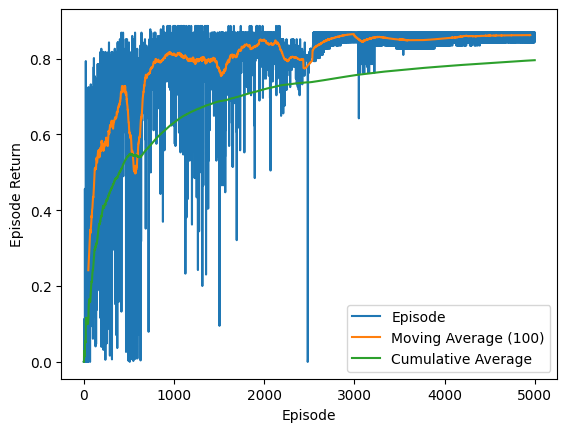

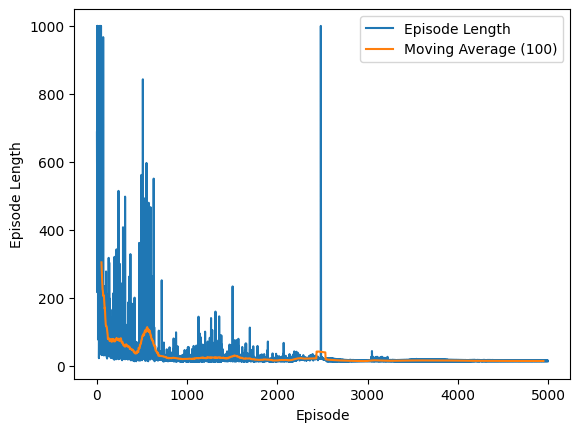

In [25]:
from gym_classics.algorithms.eligibility_traces import semi_gradient_Sarsa_lambda
gym_classics.algorithms.eligibility_traces.state_features = state_features

w, history = semi_gradient_Sarsa_lambda(env, n=5000, gamma=.99, lam = 0.1, alpha = 0.001, 
                                        epsilon = eps_schedule, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Semi-gradient Sarsa(lambda)"] = np.mean(history["returns"])
avg_ep_length["Semi-gradient Sarsa(lambda)"] = np.mean(history["ep_lens"])


REINFORCE seems to need a higher learning rate.

Episodes: 100%|██████████| 5000/5000 [02:12<00:00, 37.87it/s]


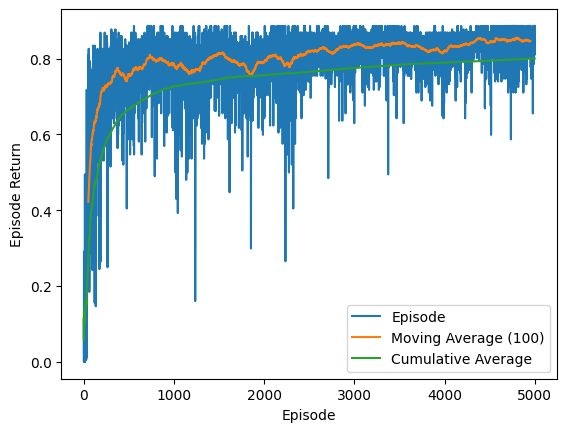

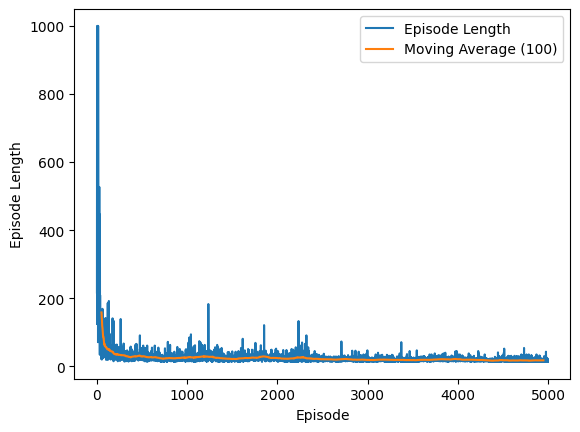

In [26]:
from gym_classics.algorithms.policy_gradient_methods import REINFORCE
gym_classics.algorithms.policy_gradient_methods.state_features = state_features

theta, history = REINFORCE(env, n= 5000, gamma=.99, alpha = .01, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["REINFORCE alpha=.01"] = np.mean(history["returns"])
avg_ep_length["REINFORCE alpha=.01"] = np.mean(history["ep_lens"])


### Compare the Average Return


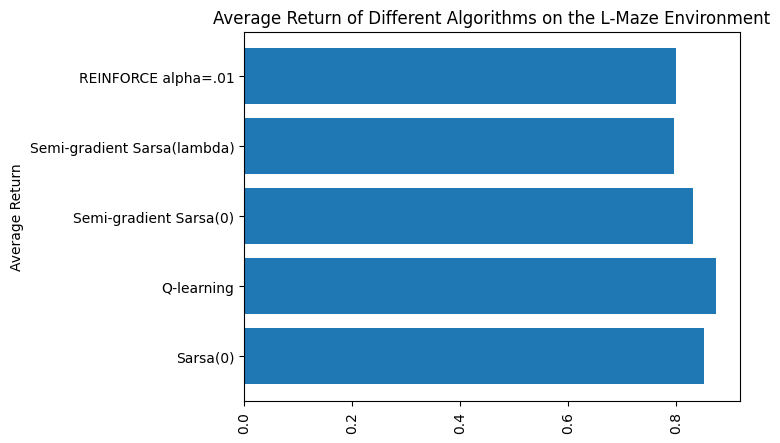

In [33]:
from matplotlib import pyplot as plt

plt.barh(avg_returns.keys(), avg_returns.values())
plt.ylabel("Average Return")
plt.title("Average Return of Different Algorithms on the L-Maze Environment")
plt.xticks(rotation=90)
plt.show()

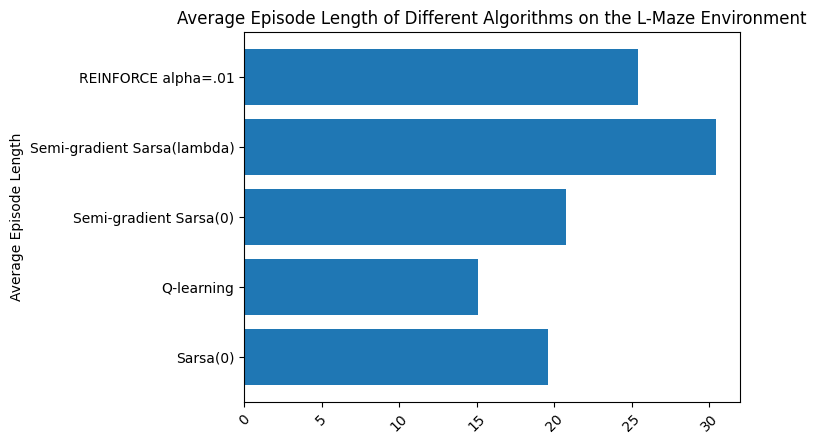

In [34]:
plt.barh(avg_ep_length.keys(), avg_ep_length.values())
plt.ylabel("Average Episode Length")
plt.title("Average Episode Length of Different Algorithms on the L-Maze Environment")
plt.xticks(rotation=45)
plt.show()


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)